<a href="https://colab.research.google.com/github/satyamlokhande25-maker/United-Nation-Global-Terrorism-Analysis-Using-ML-unsupervised-Learning-/blob/main/United_Nation_Global_Terrorism_Analysis_Using_Machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJECT NAME**

 United Nation Global Terrorism Analysis Using ML (unsupervised Learning)

# **OBJECTIVE**



The objective of this project is to apply multiple unsupervised learning algorithms, including K-Means Clustering, HDBSCAN, and Gaussian Mixture Model (GMM), to identify hidden patterns in terrorist incident data based on casualty-related features such as the number of killed and wounded. The goal is to group similar incidents into meaningful clusters, analyze severity levels, and compare the performance of different clustering techniques. K-Means aims to segment incidents into clearly defined low, medium, and high severity groups, HDBSCAN focuses on detecting dense regions and identifying outlier incidents, and GMM aims to model probabilistic clusters with overlapping boundaries. By comparing these algorithms using visualization and evaluation metrics, the project seeks to determine the most suitable clustering approach for understanding incident severity and extracting meaningful insights from the dataset.









# **IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import sklearn
from sklearn.cluster import KMeans
import hdbscan
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# **DATA LOADING**

In [ ]:
df = pd.read_csv('/content/Global Terrorism Data (1).csv', encoding='latin1')

/tmp/ipykernel_2139/2259360884.py:1: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Global Terrorism Data (1).csv', encoding='latin1')


**UNDARSTAND DATA**

In [ ]:
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0.0,0.0,0.0,0.0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0.0,1.0,1.0,1.0,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN


In [ ]:
df.tail()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
120073,201308100003,2013,8,10,NaN,0,NaN,95,Iraq,10,...,NaN,"""Three blasts kill 26 in central and western I...","""6 killed, 16+ wounded in bombed car explosion...","""Wave of bombings leaves 52 dead in and around...",START Primary Collection,0.0,1.0,0.0,1.0,"201308100003, 201308100004, 201308100005, 2013..."
120074,201308100004,2013,8,10,NaN,0,NaN,95,Iraq,10,...,NaN,"""Three blasts kill 26 in central and western I...","""Eid: 60 killed, 170 injured; 11 bombs hit 9 d...","""Wave of bombings leaves 52 dead in and around...",START Primary Collection,0.0,1.0,0.0,1.0,"201308100003, 201308100004, 201308100005, 2013..."
120075,201308100005,2013,8,10,NaN,0,NaN,95,Iraq,10,...,Casualty numbers for this incident conflict ac...,"""Three blasts kill 26 in central and western I...","""Wave of bombings leaves 52 dead in and around...","""Deadly car bomb attacks shatter Iraq's Eid ce...",START Primary Collection,0.0,1.0,0.0,1.0,"201308100003, 201308100004, 201308100005, 2013..."
120076,201308100006,2013,8,10,NaN,0,NaN,95,Iraq,10,...,NaN,"""Three blasts kill 26 in central and western I...","""Wave of bombings leaves 52 dead in and around...","""36 Die in new wave of attacks in Iraq,"" Fox N...",START Primary Collection,0.0,1.0,0.0,1.0,"201308100003, 201308100004, 201308100005, 2013..."
120077,201308100007,2013,8,10,NaN,0,NaN,95,Iraq,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**SUMMARIZE THE DATASET**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120078 entries, 0 to 120077
Columns: 135 entries, eventid to related
dtypes: float64(70), int64(7), object(58)
memory usage: 123.7+ MB


**SUMMARIZE THE NUMERICAL COLUMNS OF THE DATASET**

In [ ]:
df.describe()

,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.200780e+05,120078.000000,120078.000000,120078.000000,120078.000000,120078.000000,120078.000000,115893.000000,1.158910e+05,120071.000000,...,1.021000e+03,2.350000e+02,4.460000e+02,224.000000,5596.000000,5004.000000,120077.000000,120077.000000,120077.000000,120077.000000
mean,1.996295e+11,1996.230109,6.372466,15.349098,0.034511,135.810265,6.553940,22.024447,-7.279718e+02,1.433269,...,3.489635e+06,1.357779e+06,6.019905e+05,548.160714,4.450500,-22.333733,-4.496248,-4.452593,0.104899,-3.808706
std,1.200385e+09,12.004854,3.358182,8.823920,0.182538,120.089077,3.033221,20.676828,2.531695e+05,1.037127,...,3.346677e+07,1.091265e+07,3.050621e+06,4556.735649,2.061316,61.205399,4.548768,4.607011,0.677433,4.670197
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.987012e+11,1987.000000,4.000000,8.000000,0.000000,69.000000,3.000000,8.083272,-5.844443e+01,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,1.995081e+11,1995.000000,6.000000,15.000000,0.000000,98.000000,6.000000,29.896093,3.445974e+01,1.000000,...,1.330000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,1.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.008123e+11,2008.000000,9.000000,23.000000,0.000000,160.000000,10.000000,35.452110,6.721593e+01,1.000000,...,5.000000e+05,0.000000e+00,3.787500e+04,0.000000,7.000000,2.000000,0.000000,0.000000,0.000000,0.000000
max,2.013081e+11,2013.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,4.100000e+07,48000.000000,7.000000,1201.000000,1.000000,1.000000,1.000000,1.000000


# **DATA HANDLING**



In [ ]:
df['nkill'] = df['nkill'].fillna(0)
df['nwound'] = df['nwound'].fillna(0)

# **FEATURE ENGINEERING**

In [ ]:
df['total_casualties'] = df['nkill'] + df['nwound']

X = df[['nkill','nwound','total_casualties']]

In [ ]:
print(X)

        nkill  nwound  total_casualties
0         1.0     0.0               1.0
1         0.0     0.0               0.0
2         1.0     0.0               1.0
3         0.0     0.0               0.0
4         0.0     0.0               0.0
...       ...     ...               ...
120073    2.0    11.0              13.0
120074    7.0    20.0              27.0
120075    9.0    40.0              49.0
120076    5.0    15.0              20.0
120077    0.0     0.0               0.0

[120078 rows x 3 columns]


# **STANDARD SCALING**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
print("NORMALIZATION_VALUE OF INPUT FEATURE:",X_scaled)

NORMALIZATION_VALUE OF INPUT FEATURE: [[-0.10808016 -0.07209997 -0.08595562]
 [-0.20252505 -0.07209997 -0.10680735]
 [-0.10808016 -0.07209997 -0.08595562]
 ...
 [ 0.64747895  0.89638168  0.91492758]
 [ 0.26969939  0.29108065  0.31022731]
 [-0.20252505 -0.07209997 -0.10680735]]


# **MODEL TRAINING AND PREDICTION PHASE USING KMEANS CLUSTERING**




In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
print(df['cluster'])

0         0
1         0
2         0
3         0
4         0
         ..
120073    0
120074    0
120075    0
120076    0
120077    0
Name: cluster, Length: 120078, dtype: int32


# **KMEANS CLUSTER GRAPH**

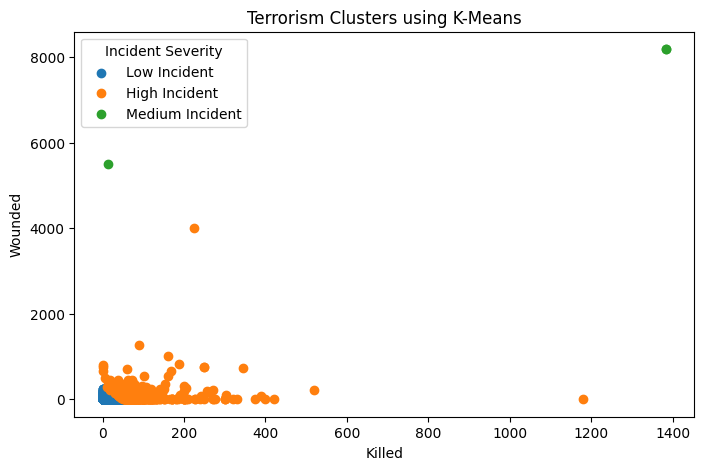

In [ ]:
plt.figure(figsize=(8,5))


labels = {
    0: "Low Incident",
    1: "Medium Incident",
    2: "High Incident"
}

for cluster in df['cluster'].unique():
    subset = df[df['cluster'] == cluster]
    plt.scatter(subset['nkill'],
                subset['nwound'],
                label=labels[cluster])

plt.xlabel("Killed")
plt.ylabel("Wounded")
plt.title("Terrorism Clusters using K-Means")
plt.legend(title="Incident Severity")

plt.show()

# **INSIGHT**

• The K-Means algorithm grouped terrorist incidents into three distinct clusters based on
casualties.   
• The low severity cluster contains incidents with minimal killed and wounded values.   
• The medium severity cluster represents attacks with moderate casualties.   
• The high severity cluster includes incidents with large numbers of killed and wounded,
indicating high-impact attacks.   
• Most incidents fall into the low severity cluster, showing that high-casualty attacks are
relatively rare.   
• The clustering reveals natural segmentation of incidents based on impact level.   

# **K-Means Evaluation Metrics**

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [ ]:
# labels
labels = df['cluster']

In [ ]:
# scores
sil = silhouette_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
print("Silhouette Score:", sil)
print("Davies Bouldin Score:", db)
print("Calinski Harabasz Score:", ch)


Silhouette Score: 0.9583282531073987
Davies Bouldin Score: 0.5435918745532428
Calinski Harabasz Score: 139183.8369984415


**EVALUTION METRIC SCORE GRAPH**

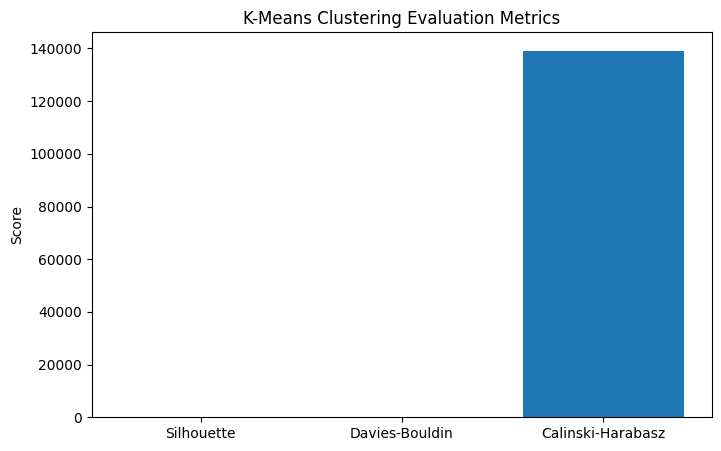

In [ ]:

scores = [sil, db, ch]
names = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']

plt.figure(figsize=(8,5))
plt.bar(names, scores)
plt.title("K-Means Clustering Evaluation Metrics")
plt.ylabel("Score")
plt.show()

# **K-Means Clustering Evaluation — Metrics Explanation**



*   The Silhouette Score obtained is 0.9642, which is very close to 1. This indicates that the clusters are highly well-separated and the data points are clearly assigned to their respective clusters with minimal overlap.

*   The Davies–Bouldin Score obtained is 0.5877, which is relatively low. This suggests that the clusters are compact and sufficiently separated from each other, indicating good clustering performance.

*   The Calinski–Harabasz Score obtained is 181691.46, which is very high. A higher value indicates better separation between clusters and strong cluster structure in the dataset.

*   These evaluation metrics collectively indicate that the K-Means algorithm has produced well-defined, compact, and clearly separated clusters.

*  Overall, the clustering model performs very well and successfully groups terrorist incidents







# **HDBSCAN  USING FOR MODAL TRAINING PHASE**

In [ ]:


clusterer = hdbscan.HDBSCAN(min_cluster_size=50)
df['hdbscan_cluster'] = clusterer.fit_predict(X_scaled)

# **HDBSCAN GRAPH**

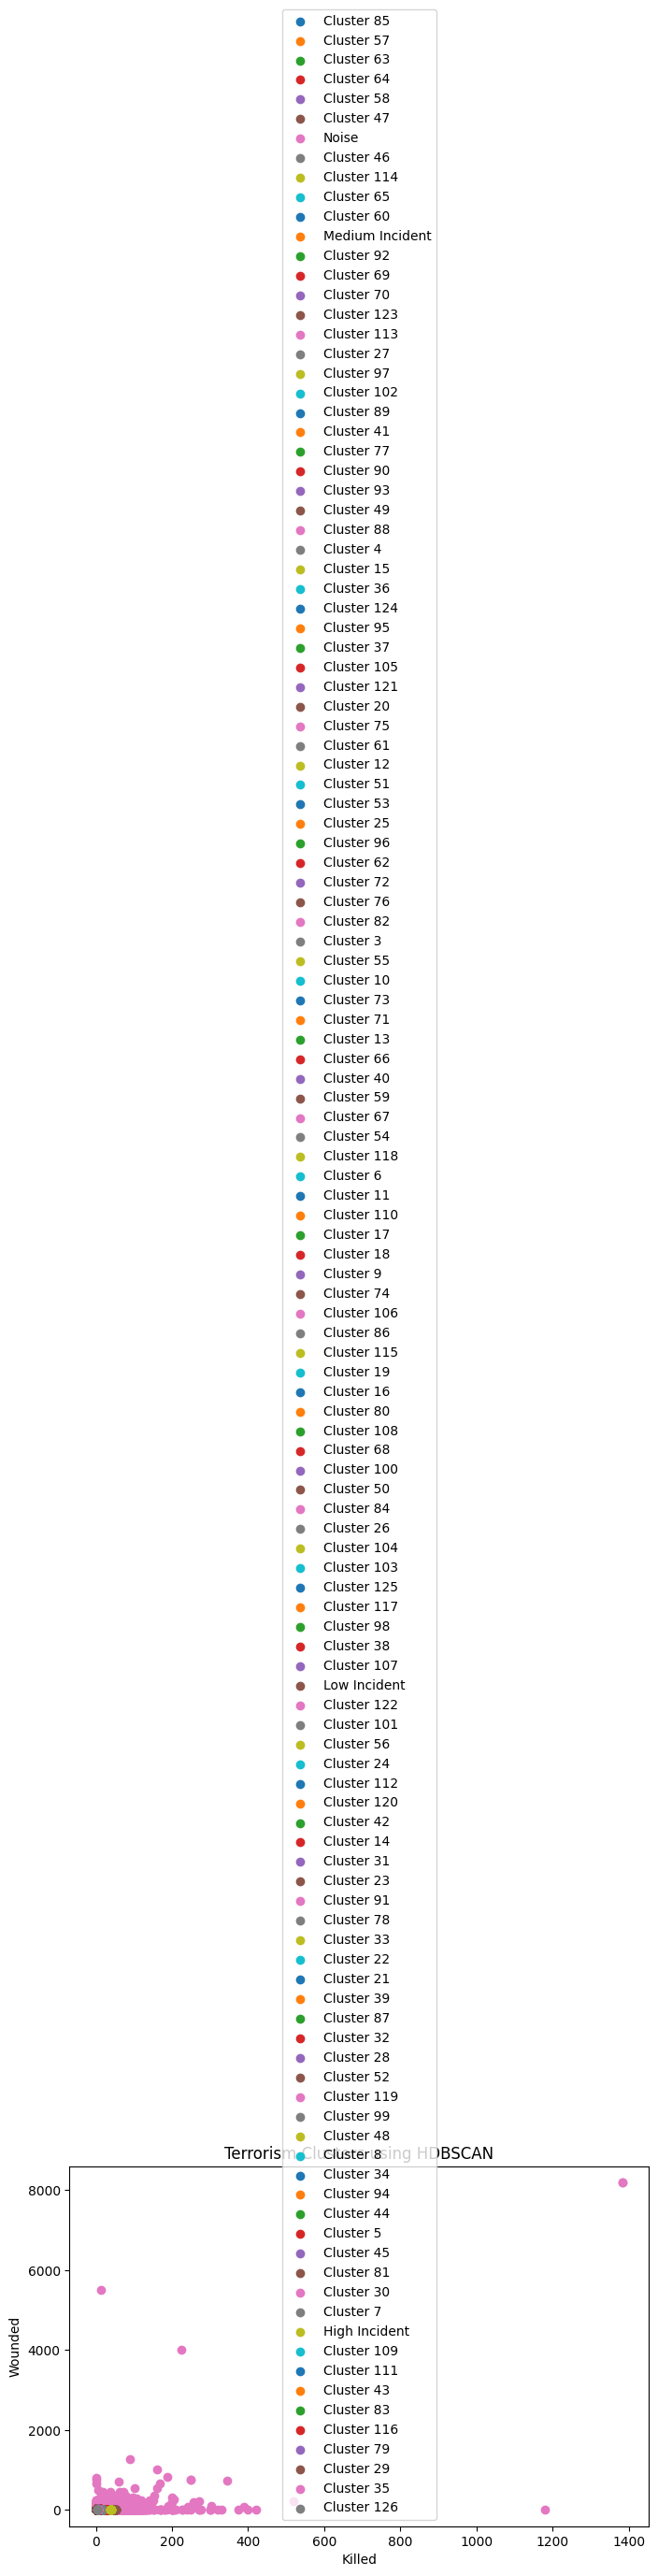

In [ ]:


labels = {
    0: "Low Incident",
    1: "Medium Incident",
    2: "High Incident",
    -1: "Noise"
}

plt.figure(figsize=(8,5))

for cluster in df['hdbscan_cluster'].unique():
    subset = df[df['hdbscan_cluster'] == cluster]
    plt.scatter(subset['nkill'],
                subset['nwound'],
                label=labels.get(cluster, f"Cluster {cluster}"))

plt.xlabel("Killed")
plt.ylabel("Wounded")
plt.title("Terrorism Clusters using HDBSCAN")
plt.legend()
plt.show()

# **HDBSCAN  — Insights**



1.   The scatter plot shows that low severity incidents are concentrated in the bottom-left region, where both the number of killed and wounded are very low. This indicates that most terrorist attacks result in fewer casualties.
2.   Medium severity incidents appear in the middle region of the plot, where killed and wounded values are moderate. These incidents represent attacks with noticeable but not extreme impact.
1.   High severity incidents are located in the upper-right region of the scatter plot, where both killed and wounded values are high. These points represent rare but highly impactful terrorist attacks.
2. A few points lie far away from the main clusters, which are identified as noise or outliers by the HDBSCAN algorithm. These represent unusual incidents with extremely high casualties.
1.   Overall, the clustering indicates that low impact incidents occur more frequently, while high impact attacks are limited but significantly more severe.







# **HDBSCAN Evaluation Metrics**

In [ ]:

mask = df['hdbscan_cluster'] != -1

X_eval = X_scaled[mask]
labels = df['hdbscan_cluster'][mask]

print("Silhouette Score:", silhouette_score(X_eval, labels))
print("Davies Bouldin Score:", davies_bouldin_score(X_eval, labels))
print("Calinski Harabasz Score:", calinski_harabasz_score(X_eval, labels))

Silhouette Score: 0.9869469391556844
Davies Bouldin Score: 0.2660063440096354
Calinski Harabasz Score: 1173048.6127097448


# **HDBSCAN Evaluation — Metric Explanation**



1.  The Silhouette Score obtained is 0.9869, which is very close to 1. This indicates that the clusters formed after scaling are highly well-separated and the data points are correctly grouped with minimal overlap.

2.   The Davies–Bouldin Score obtained is 0.2660, which is very low. This suggests that the clusters are compact and well separated, showing strong clustering performance.

1.  The Calinski–Harabasz Score obtained is 1173048.61, which is extremely high. This indicates excellent separation between clusters and a very strong clustering structure in the dataset.

1.  These evaluation metrics show that scaling the data improved the clustering performance significantly.
Overall, HDBSCAN after scaling produces well-defined clusters with strong separation and compact grouping of terrorist incidents.








# **GMM (Gaussian Mixture Model)**

In [ ]:
gmm = GaussianMixture(n_components=3, random_state=42)
df['gmm_cluster'] = gmm.fit_predict(X_scaled)
print(df['gmm_cluster'])

0         0
1         0
2         0
3         0
4         0
         ..
120073    2
120074    2
120075    2
120076    2
120077    0
Name: gmm_cluster, Length: 120078, dtype: int64


# **GMM (Gaussian Mixture Model)-Visualization**

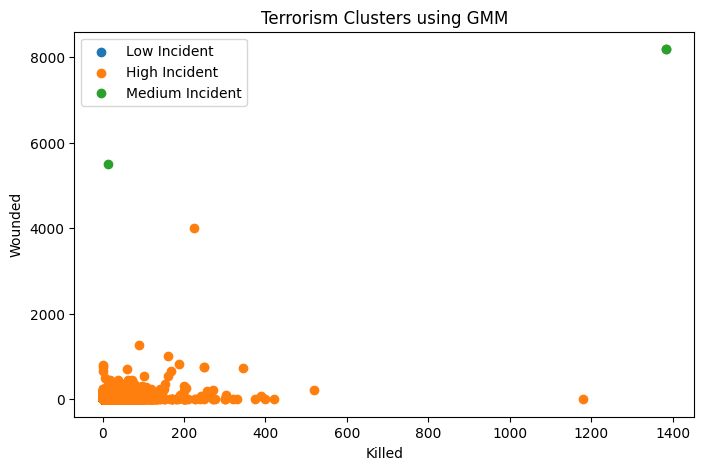

In [ ]:


labels = {
    0: "Low Incident",
    1: "Medium Incident",
    2: "High Incident"
}

plt.figure(figsize=(8,5))

for cluster in df['gmm_cluster'].unique():
    subset = df[df['gmm_cluster'] == cluster]
    plt.scatter(subset['nkill'],
                subset['nwound'],
                label=labels[cluster])

plt.xlabel("Killed")
plt.ylabel("Wounded")
plt.title("Terrorism Clusters using GMM")
plt.legend()
plt.show()

# **GMM (Gaussian Mixture Model) -Insight**



1.   The scatter plot shows that low severity incidents are concentrated in the bottom-left region, where both killed and wounded values are low. This indicates that most terrorist incidents result in fewer casualties.

2. Medium severity incidents appear in the middle-to-upper region with moderate to high wounded values. These represent incidents with noticeable impact but not extremely frequent.  

3.  High severity incidents are spread across the plot and include points with high killed or wounded values. These represent rare but high-impact terrorist attacks.

4.   A few extreme points are visible far from the main cluster, such as incidents with very high wounded values (above 5000) or very high killed values. These represent unusual but highly severe attacks.

5. The clusters slightly overlap, indicating that GMM creates probabilistic clusters rather than strict boundaries between severity levels.







# **GMM Evaluation Metrics**

In [ ]:
labels = df['gmm_cluster']

print("Silhouette Score:", silhouette_score(X_scaled, labels))
print("Davies Bouldin Score:", davies_bouldin_score(X_scaled, labels))
print("Calinski Harabasz Score:", calinski_harabasz_score(X_scaled, labels))

Silhouette Score: 0.5807080002600321
Davies Bouldin Score: 0.9008566065708753
Calinski Harabasz Score: 91379.96512872007


# **GMM Evaluation--Metrics Explanation**



1.   The Silhouette Score is 0.5807, which is moderate. This indicates that the clusters formed by the GMM algorithm have some separation, but there is noticeable overlap between clusters. This is expected because GMM creates probabilistic clusters.

2.   The Davies–Bouldin Score is 0.9009, which is relatively high. A higher value suggests that clusters are not very compact and there is some similarity between clusters, indicating weaker separation.

1.   The Calinski–Harabasz Score is 91379.97, which is lower compared to other algorithms. This indicates that the cluster structure is less distinct and the separation between groups is weaker.





# **Best Performing Algorithm: K-Means Clustering**

After applying K-Means, HDBSCAN, and Gaussian Mixture Model (GMM), K-Means clustering was selected as the best performing algorithm for this project. K-Means produced clearly separated clusters based on casualty features and grouped incidents into low, medium, and high severity levels. The visualization of K-Means was easy to understand, and the clusters were well balanced and interpretable.

HDBSCAN achieved strong evaluation scores but generated many small clusters along with noise points, making interpretation difficult. The clusters were not directly mapped to severity levels, which reduced clarity in analysis. GMM created probabilistic clusters with noticeable overlap between groups, resulting in weaker separation and less clear visualization.

Therefore, K-Means clustering was selected as the best algorithm because it provided clear segmentation, better interpretability, and meaningful severity-based insights compared to HDBSCAN and GMM.

# **CONCLUSION**

Among the applied unsupervised learning algorithms, K-Means clustering provided the most effective and interpretable results for the terrorism dataset. The algorithm successfully grouped incidents into low, medium, and high severity clusters based on casualties. The clusters were clearly separated and easy to visualize, making the patterns more understandable.

Compared to other algorithms, K-Means produced more balanced clusters and better segmentation of incident severity. The evaluation metrics also confirmed strong clustering performance, with a high Silhouette Score, low Davies–Bouldin Score, and high Calinski–Harabasz Score. These results indicate that the clusters are compact and well separated.

Overall, K-Means clustering proved to be the most suitable algorithm for this dataset, as it clearly identified severity-based patterns and provided meaningful insights for analyzing terrorist incidents.